In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "NdLinear") 
from ndlinear import NdLinear

# 2) Data loading
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])
train_ds = datasets.CIFAR10(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.CIFAR10(root="data", train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
]))
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=4)
test_dl  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=4)


100%|██████████| 170M/170M [00:20<00:00, 8.15MB/s] 


In [3]:
# 3) Model definitions
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [4]:
# helper to flatten in Sequential
class Flatten(nn.Module):
    def forward(self, x): return x.view(x.size(0), -1)

# 1) Build two factory functions that return fresh models
def make_baseline():
    return nn.Sequential(
        # conv‐pool backbone
        *list(BaselineCNN().features.children()),
        # flatten + MLP head
        Flatten(),
        nn.Linear(8*8*64, 256), nn.ReLU(),
        nn.Linear(256, 10),
    )

def make_ndlinear():
    return nn.Sequential(
        # same conv‐pool backbone
        *list(BaselineCNN().features.children()),
        # NdLinear head (invokes NdLinear.forward internally)
        NdLinear(input_dims=(64,8,8), hidden_size=(32,8,8)),
        nn.ReLU(),
        # flatten + MLP head
        Flatten(),
        nn.Linear(32*8*8, 256), nn.ReLU(),
        nn.Linear(256, 10),
    )

In [7]:
# 4) Utility and experiment functions
import time

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, opt, criterion, dl, device):
    model.train()
    total, correct, loss_sum = 0,0,0.0
    for xb,yb in dl:
        xb,yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss   = criterion(logits,yb)
        loss.backward()
        opt.step()
        loss_sum += loss.item()*xb.size(0)
        preds = logits.argmax(1)
        correct += (preds==yb).sum().item()
        total   += xb.size(0)
    return loss_sum/total, correct/total

def eval_model(model, criterion, dl, device):
    model.eval()
    total, correct, loss_sum = 0,0,0.0
    with torch.no_grad():
        for xb,yb in dl:
            xb,yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits,yb)
            loss_sum += loss.item()*xb.size(0)
            preds = logits.argmax(1)
            correct += (preds==yb).sum().item()
            total   += xb.size(0)
    return loss_sum/total, correct/total

def run_experiment(ModelClass, epochs=20, eval_freq=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = ModelClass().to(device)

    # Init NdLinear per‐mode weights
    for m in model.modules():
        if isinstance(m, NdLinear):
            for layer in m.align_layers:
                nn.init.xavier_uniform_(
                    layer.weight,
                    gain=nn.init.calculate_gain('relu')
                )
                nn.init.zeros_(layer.bias)

    opt    = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    crit   = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler() if device.type=='cuda' else None

    history = {'train_acc':[], 'test_acc':[], 'epoch_time':[]}
    print(f"Params: {count_params(model):,}")

    for ep in range(1, epochs+1):
        # — TRAINING PASS (timed) —
        t0 = time.time()
        model.train()
        total, correct = 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            if scaler:
                with torch.cuda.amp.autocast():
                    logits = model(xb)
                    loss   = crit(logits, yb)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                logits = model(xb)
                loss   = crit(logits, yb)
                loss.backward()
                opt.step()

            preds   = logits.argmax(1)
            correct += (preds==yb).sum().item()
            total   += yb.size(0)

        train_acc = correct/total
        train_time = time.time() - t0
        history['train_acc'].append(train_acc)
        history['epoch_time'].append(train_time)

        # — EVALUATION PASS (every eval_freq epochs + last epoch) —
        if ep % eval_freq == 0 or ep == epochs:
            _, test_acc = eval_model(model, crit, test_dl, device)
            history['test_acc'].append(test_acc)
            print(f"Ep{ep:02d}  train: {train_acc:.3%}  "
                  f"test: {test_acc:.3%}  "
                  f"train_time: {train_time:.1f}s")
        else:
            print(f"Ep{ep:02d}  train: {train_acc:.3%}  "
                  f"(train_time: {train_time:.1f}s)")

    return model, history




In [15]:
# 1) Run Baseline first
print("\n=== Baseline ===")
baseline_model, baseline_hist = run_experiment(make_baseline, epochs=20)


=== Baseline ===
Params: 1,070,794
Ep01  train: 37.124%  (train_time: 53.7s)
Ep02  train: 47.378%  (train_time: 54.2s)
Ep03  train: 51.602%  (train_time: 52.2s)
Ep04  train: 55.138%  (train_time: 50.7s)
Ep05  train: 57.476%  test: 63.060%  train_time: 61.1s
Ep06  train: 59.620%  (train_time: 69.1s)
Ep07  train: 61.382%  (train_time: 66.0s)
Ep08  train: 62.412%  (train_time: 63.7s)
Ep09  train: 63.660%  (train_time: 71.4s)
Ep10  train: 64.968%  test: 69.030%  train_time: 84.4s
Ep11  train: 65.880%  (train_time: 82.1s)
Ep12  train: 66.402%  (train_time: 82.7s)
Ep13  train: 67.550%  (train_time: 80.3s)
Ep14  train: 68.122%  (train_time: 80.7s)
Ep15  train: 68.968%  test: 71.790%  train_time: 82.3s
Ep16  train: 69.542%  (train_time: 83.3s)
Ep17  train: 69.810%  (train_time: 85.4s)
Ep18  train: 70.618%  (train_time: 86.7s)
Ep19  train: 71.284%  (train_time: 86.0s)
Ep20  train: 71.842%  test: 74.080%  train_time: 85.6s


In [16]:
# 2) Then run NdLinear
print("\n=== NdLinear ===")
nd_model, nd_hist = run_experiment(make_ndlinear, epochs=20)


=== NdLinear ===
Params: 548,730
Ep01  train: 38.224%  (train_time: 52.4s)
Ep02  train: 49.440%  (train_time: 51.6s)
Ep03  train: 53.768%  (train_time: 52.7s)
Ep04  train: 57.226%  (train_time: 52.9s)
Ep05  train: 59.584%  test: 64.770%  train_time: 53.6s
Ep06  train: 61.756%  (train_time: 52.6s)
Ep07  train: 63.608%  (train_time: 54.7s)
Ep08  train: 65.086%  (train_time: 53.6s)
Ep09  train: 66.456%  (train_time: 53.7s)
Ep10  train: 67.518%  test: 70.740%  train_time: 55.0s
Ep11  train: 68.578%  (train_time: 54.7s)
Ep12  train: 69.504%  (train_time: 55.7s)
Ep13  train: 70.694%  (train_time: 56.9s)
Ep14  train: 71.220%  (train_time: 55.5s)
Ep15  train: 71.930%  test: 73.650%  train_time: 55.9s
Ep16  train: 72.642%  (train_time: 56.2s)
Ep17  train: 73.208%  (train_time: 54.8s)
Ep18  train: 73.804%  (train_time: 55.3s)
Ep19  train: 74.516%  (train_time: 56.5s)
Ep20  train: 75.156%  test: 75.350%  train_time: 56.6s


In [17]:
# 4) Print a quick side-by-side summary
print("\nModel       AvgTrainTime(s)   FinalTestAcc(%)")
print("-"*45)
base_t = sum(baseline_hist['epoch_time']) / len(baseline_hist['epoch_time'])
base_acc = baseline_hist['test_acc'][-1] * 100
nd_t   = sum(nd_hist      ['epoch_time']) / len(nd_hist      ['epoch_time'])
nd_acc = nd_hist      ['test_acc'][-1] * 100

print(f"{'Baseline':<12}{base_t:>15.2f}{base_acc:>18.2f}")
print(f"{'NdLinear':<12}{nd_t:>15.2f}{nd_acc:>18.2f}")


Model       AvgTrainTime(s)   FinalTestAcc(%)
---------------------------------------------
Baseline              73.08             74.08
NdLinear              54.54             75.35


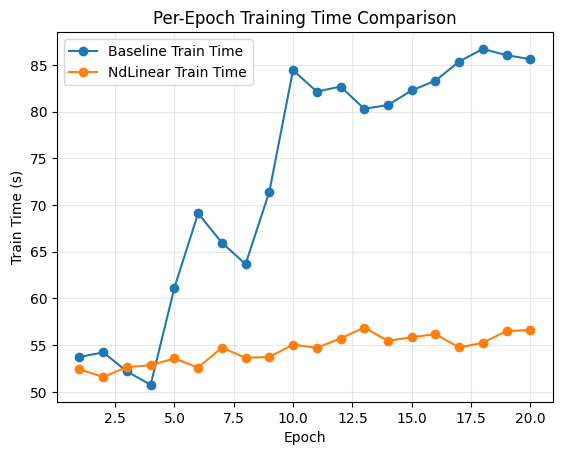

In [18]:
# 5) And plot their train-time curves
import matplotlib.pyplot as plt
epochs = range(1, 21)
plt.figure()
plt.plot(epochs, baseline_hist['epoch_time'], '-o', label='Baseline Train Time')
plt.plot(epochs, nd_hist      ['epoch_time'], '-o', label='NdLinear Train Time')
plt.xlabel('Epoch'); plt.ylabel('Train Time (s)')
plt.title('Per-Epoch Training Time Comparison')
plt.legend(); plt.grid(alpha=0.3); plt.show()